<h1 style="font-size:25px; font-weight:700; margin-bottom:0px;">
Comparing Linear and Ensemble Methods for Customer Subscription Prediction
</h1>

<span style="font-size:24px; font-family:'Times New Roman', Times, serif; margin-top:0px;">
<i>An empirical evaluation of logistic regression, random forest, and gradient boosting models</i>
</span>


## Abstract

This study evaluates several supervised learning approaches for predicting customer subscription outcomes using a structured marketing dataset. Three classification models were considered: <b>logistic regression</b>, <b>random forest</b>, and <b>gradient boosting</b>. Model performance was first assessed using a hold-out training and test split and then evaluated more rigorously using Monte Carlo cross-validation with 100 random replications to obtain more stable estimates of predictive performance. Both misclassification error and the area under the receiver operating characteristic curve (AUC) were used to assess model accuracy and classification discrimination.

The results indicate that all three models achieve broadly relatively predictive performance, although the ensemble methods provide modest improvements over the baseline logistic regression model. In the hold-out evaluation, the gradient boosting model achieves the highest test AUC (0.7990) and the lowest test error (0.1064). Monte Carlo cross-validation across 100 replications produces similar patterns, with the random forest achieving the lowest mean test error (0.1054) and the boosting model producing the highest mean AUC (0.7990). The relatively small standard deviations of the test error and AUC across the Monte Carlo replications indicate that model performance is stable across different random training and test partitions.

Feature importance analysis highlights several features that consistently influence model predictions, particularly `poutcome_success`, which emerges as a key predictor across all models. The tree-based models also emphasize continuous customer characteristics such as `balance`, `age`, and `day`, while logistic regression places greater weight on campaign-related categorical predictors including `contact_unknown`, `housing`, and seasonal `month` indicators. These differences illustrate how linear and tree-based models capture distinct aspects of the predictive structure in the data.

Overall, while all three approaches demonstrate similar predictive capability, the boosting model achieves the highest average AUC across repeated samples, indicating slightly stronger discrimination between subscription and non-subscription outcomes. Because AUC measures a model’s ability to discriminate between classes across all classification thresholds, it provides a more comprehensive assessment of predictive performance than a single threshold-based misclassification error. As a result, <b><u>the gradient boosting model is selected as the final predictive model</u></b> due to its strong classification discrimination and flexibility in capturing nonlinear relationships and interactions among predictors.


## Introduction

Predicting customer response to marketing efforts is an important problem in banking and financial services, where institutions seek to identify customers who are most likely to subscribe to financial products. Accurate prediction models can improve the efficiency of marketing activities by targeting customers with a higher probability of responding positively, which reduces marketing costs and increases campaign effectiveness. This study analyzes a structured marketing dataset that includes customer demographic characteristics, financial information, and historical contact records from previous marketing campaigns. The objective is to predict whether a customer will subscribe to a term deposit<span style="color: darkred; font-weight: bold;"><sup>1</sup></span> using this data.

To address this problem, three supervised classification approaches are evaluated: <b>logistic regression</b>, <b>random forest</b>, and <b>gradient boosting</b>. Logistic regression serves as an interpretable baseline model, while the ensemble tree-based methods provide more flexible modeling frameworks capable of capturing nonlinear relationships and interactions among predictors. Model performance is first assessed using a hold-out training and test split and then evaluated more rigorously using Monte Carlo cross-validation across 100 replications. Predictive performance is measured using misclassification error and the area under the receiver operating characteristic curve (AUC), allowing both classification accuracy and discrimination ability to be compared across models.

By comparing the predictive performance of linear and ensemble approaches, this study seeks to determine whether more flexible machine learning methods provide meaningful improvements in predicting customer subscription outcomes while also identifying the predictors that most strongly influence customer response behavior.

---

<div style="margin-left:20px; text-indent:-10px;">
<span style="color: darkred; font-weight: bold;"><sup>1</sup></span> 
    Term deposit is a fixed-term savings product offered by banks.
</div>


### *Initialize Environment*

The analysis begins by importing the Python libraries required for data manipulation, visualization, model estimation, and performance evaluation. Numerical and tabular operations are performed using NumPy and pandas, while matplotlib and seaborn are used for data visualization. The scikit-learn library provides tools for preprocessing, model training, and performance evaluation, including implementations of logistic regression, random forests, and gradient boosting. It also provides classification metrics such as accuracy, confusion matrices, and receiver operating characteristic (ROC) curves for assessing model performance.


In [1]:
# Core Libraries
import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Scikit-Learn: Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Scikit-Learn: Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Scikit-Learn: Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Scikit-Learn: Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Number of Available Processors
os.cpu_count()


10

### *Utility Functions*

To support the presentation of model results, several utility functions are defined to standardize the formatting of tables and evaluation outputs. These helper functions improve readability and ensure consistent reporting across models and experiments. In particular, a row-highlighting function emphasizes selected rows in tables, while a custom confusion matrix display function presents classification results in a clear and structured format.


In [2]:
# Row Highlight
def highlight_rows(target_rows):
    if not isinstance(target_rows, (list, tuple, set)):
        target_rows = [target_rows]
        
    def _highlight(row):
        return [
            'background-color: #fff3cd; font-weight: bold'
            if row.name in target_rows else ''
            for _ in row
        ]
    return _highlight

# Confusion Matrix
def display_confusion_matrix(cm, title):

    display(HTML(f"""
    <br>
    <b>{title}</b>
    <table style='border-collapse: collapse; font-size:14px'>
        <tr>
            <th></th>
            <th>Predicted 0</th>
            <th>Predicted 1</th>
        </tr>
        <tr>
            <th>Actual 0</th>
            <td style='padding:6px;border:1px solid #ccc'>{cm[0,0]}</td>
            <td style='padding:6px;border:1px solid #ccc'>{cm[0,1]}</td>
        </tr>
        <tr>
            <th>Actual 1</th>
            <td style='padding:6px;border:1px solid #ccc'>{cm[1,0]}</td>
            <td style='padding:6px;border:1px solid #ccc'>{cm[1,1]}</td>
        </tr>
    </table>
    """))


### Bank Marketing Dataset

The dataset used in this study is the Bank Marketing dataset obtained from the UCI Machine Learning Repository<span style="color: darkred; font-weight: bold;"><sup>2</sup></span>. The data originates from direct marketing campaigns conducted by a Portuguese banking institution, where customers were contacted by phone and offered a term deposit product. The dataset was created to study customer responses to these marketing campaigns using demographic characteristics, financial information, and prior marketing interactions. The dataset contains 45,211 observations and 16 variables describing attributes such as age, occupation, marital status, education level, account balance, loan status, and previous marketing interactions. The target variable, denoted as `y`, is a binary indicator that records whether the customer subscribed to the term deposit (“yes”) or not (“no”).

---

<div style="margin-left:20px; text-indent:-10px;">
<span style="color: darkred; font-weight: bold;"><sup>2</sup></span> 
    Moro, S., Rita, P., & Cortez, P. (2014). Bank Marketing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306.
</div>


In [3]:
# Load Data & Response Variable Construction
df = pd.read_csv('data/bank-full.csv', sep = ';')

display(HTML(f"""</br>
    Initial Dataset Shape: 
    <span style='background-color: #fff3b0; font-weight: bold; padding: 2px 4px;'>
         {df.shape}
    </span>
"""))

display(df.head(5))


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Data Preprocessing

Prior to model development, several preprocessing steps were performed to prepare the dataset for analysis. In this study, preprocessing included verifying data quality, confirming the absence of missing values, removing variables that could introduce information leakage, and converting categorical variables into a numerical format compatible with classification models. These steps ensure that the resulting dataset reflects the information available at the time of the marketing decision and that the predictive models are trained on consistent and reliable input features.


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Missing Data Analysis.
</span> 
A preliminary analysis was conducted to assess the presence of missing values across all variables in the dataset. The results indicate that the Bank Marketing dataset contains no missing observations, with each variable reporting a missing count of zero. While some categorical variables include the category “unknown,” these entries represent valid responses rather than missing data.


In [4]:
# Missing Data Analysis
missing_summary = df.isnull().sum().to_frame('missing_count')
missing_summary['missing_percent'] = (
    missing_summary['missing_count'] / len(df) * 100
)

display(missing_summary.head(5))


,missing_count,missing_percent
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Removal of Post-Outcome Variable.
</span> 
The variable <code>duration</code>, which records the length of the last contact with a customer in seconds, was excluded from the modeling process because it is measured only after the marketing call has been completed. Including this variable would introduce information leakage because it is highly correlated with the outcome but would not be available at the time a marketing decision is made. Because the objective of the analysis is to predict whether a customer will subscribe to a term deposit before or during the marketing campaign, including <code>duration</code> would produce unrealistically optimistic model performance.


In [5]:
# Variable Selection/Removal
df = df.drop(columns = ['duration'])


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Class Balance Assessment.
</span> 
The distribution of the target variable <code>y</code> is examined to assess the degree of class imbalance in the dataset. In the Bank Marketing dataset, approximately 88.3% of observations correspond to customers who did not subscribe to a term deposit (y = “no”), while 11.7% represent successful subscriptions (y = “yes”). This imbalance is typical in marketing response data, where positive responses are relatively infrequent.


In [6]:
# Class Balance Assessment
class_counts = df['y'].value_counts(normalize = True)

display(HTML(f"""</br>
    <b>Class Proportion</b></br>
    
    y = no: 
    <span style='background-color: #fff3b0; font-weight: bold; padding: 2px 4px;'>
         {class_counts.iloc[0]:.4f}
    </span></br>

    y = yes: 
    <span style='background-color: #fff3b0; font-weight: bold; padding: 2px 4px;'>
         {class_counts.iloc[1]:.4f}
    </span>
"""))


## Exploratory Data Analysis (EDA)

Exploratory data analysis (EDA) was conducted to better understand the structure and characteristics of the dataset prior to model development. The purpose of this stage is to examine the distribution of key variables, identify potential patterns in the data, and assess relationships between variables and the target. In this study, the EDA focuses on summary statistics, class balance, and visualizations of selected variables to obtain insight into how demographic characteristics, financial attributes, and prior marketing interactions relate to the likelihood that a customer subscribes to a term deposit.


### Data Structure & Summary Statistics

The dataset contains six numeric variables and nine categorical variables, with no missing observations. The numeric variables summarize customer demographics and campaign activity. As shown in <b>Table 1</b>, the variable `age` ranges from 18 to 95 years with a mean of approximately 40.9 years, indicating a broad distribution of customer ages. The variable `balance`, representing the customer’s average yearly bank balance, displays substantial variability and a wide range from −8,019 to over 102,000 euros, suggesting considerable heterogeneity in customers’ financial positions. Campaign-related variables such as `campaign`, `pdays`<span style="color: darkred; font-weight: bold;"><sup>3</sup></span>, and `previous` show strong concentration at low values, indicating that most customers were contacted only a small number of times and that many had not been contacted in previous marketing campaigns. The variable `day`, representing the day of the month when the last contact occurred, spans the full range from 1 to 31.

---

<div style="margin-left:20px; text-indent:-10px;">
<span style="color: darkred; font-weight: bold;"><sup>3</sup></span> 
    The variable pdays, which measures the number of days since a customer was last contacted in a previous campaign, takes the value −1 for customers who had not been previously contacted, resulting in a large concentration of observations at −1.
</div>


In [7]:
# Data Structure & Summary Statistics
numeric_vars = df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
categorical_vars = df.select_dtypes(include = ['object', 'category']).columns.tolist()

numeric_vars = [v for v in numeric_vars if v != 'y']
categorical_vars = [v for v in categorical_vars if v != 'y']

display(HTML(f"""
    <b>Variable Summary</b><br>
    
    Numeric Predictors:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {len(numeric_vars)}
    </span><br>
    
    Categorical Predictors:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {len(categorical_vars)}
    </span>
"""))

numeric_summary = (
    df[numeric_vars]
    .describe()
    .T
    .assign(
        missing_pct = df[numeric_vars]
        .isna()
        .mean()
        .mul(100)
    )
    .reset_index()
    .rename(columns = {'index': 'Variable'})
)

display(HTML('<br><b>Table 1: Summary Statistics for Numeric Variables</b>'))
display(
    numeric_summary
        .style
        .hide(axis = 'index')
        .format({
            'count': '{:,.0f}',
            'mean': '{:,.2f}',
            'std': '{:,.2f}',
            'min': '{:,.0f}',
            '25%': '{:.2f}',
            '50%': '{:.2f}',
            '75%': '{:.2f}',
            'max': '{:,.0f}',
            'missing_pct': '{:.2f}'
        })
        .set_properties(subset = ['Variable'], **{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'th.col_heading.level0.col0',
             'props': [('text-align', 'left')]}
        ])
)


Variable,count,mean,std,min,25%,50%,75%,max,missing_pct
age,"45,211",40.94,10.62,18,33.00,39.00,48.00,95,0.00
balance,"45,211","1,362.27","3,044.77","-8,019",72.00,448.00,1428.00,"102,127",0.00
day,"45,211",15.81,8.32,1,8.00,16.00,21.00,31,0.00
campaign,"45,211",2.76,3.10,1,1.00,2.00,3.00,63,0.00
pdays,"45,211",40.20,100.13,-1,-1.00,-1.00,-1.00,871,0.00
previous,"45,211",0.58,2.30,0,0.00,0.00,0.00,275,0.00


As shown in **Table 2**, the dataset contains nine categorical variables describing customer characteristics and marketing campaign attributes. These variables include demographic factors such as `job`, `marital`, and `education`, as well as financial indicators such as `default`, `housing`, and `loan`. Additional variables describe aspects of the marketing campaign, including the contact communication type (`contact`), the month of contact (`month`), and the outcome of any previous campaign (`poutcome`). The number of categories varies significantly, ranging from two categories for binary indicators such as `default` and `housing` to twelve categories for `job` and `month`.


In [8]:
# Categorical Summary Table
categorical_summary = (
    pd.DataFrame({
        'Variable': categorical_vars,
        'Num Categories': [df[var].nunique() for var in categorical_vars],
        'Missing (%)': [df[var].isna().mean() * 100 for var in categorical_vars]
    })
)

display(HTML('<br><b>Table 2: Summary Statistics for Categorical Variables</b>'))
display(
    categorical_summary
        .style
        .hide(axis = 'index')
        .format({
            'Num Categories': '{:,.0f}',
            'Missing (%)': '{:.2f}'
        })
        .set_properties(subset = ['Variable'], **{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'th.col_heading.level0.col0',
             'props': [('text-align', 'left')]}
        ])
)


Variable,Num Categories,Missing (%)
job,12,0.00
marital,3,0.00
education,4,0.00
default,2,0.00
housing,2,0.00
loan,2,0.00
contact,3,0.00
month,12,0.00
poutcome,4,0.00


### Numeric Variable Analysis

The numeric variables provide additional insight into customer characteristics and marketing campaign activity. Several campaign-related variables display right-skewed distributions. For example, `campaign`, the number of contacts during the current marketing campaign, is concentrated at small values, suggesting most customers were contacted only a few times. Similarly, `previous`, the number of contacts prior to the current campaign, is dominated by small counts. The variable `pdays` shows substantial dispersion and a large mass at −1. 


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Numeric Variable Distributions.
</span>
The distributions of the numeric variables are summarized in <b>Figure 1</b>. The variable <code>age</code> shows moderate dispersion with a distribution centered around middle-aged customers and a mild right tail reflecting older customers. In contrast, <code>balance</code> shows strong right skewness, with most customers holding relatively modest balances and a small number of observations extending to very large values. Campaign-related variables such as <code>campaign</code> and <code>previous</code> are heavily concentrated at small counts, indicating that most customers were contacted only a few times both during and prior to the current campaign. The variable <code>pdays</code> also shows strong concentration at low values with a long right tail. Finally, <code>day</code> spans the full range from 1 to 31, indicating that contacts occurred throughout the month.

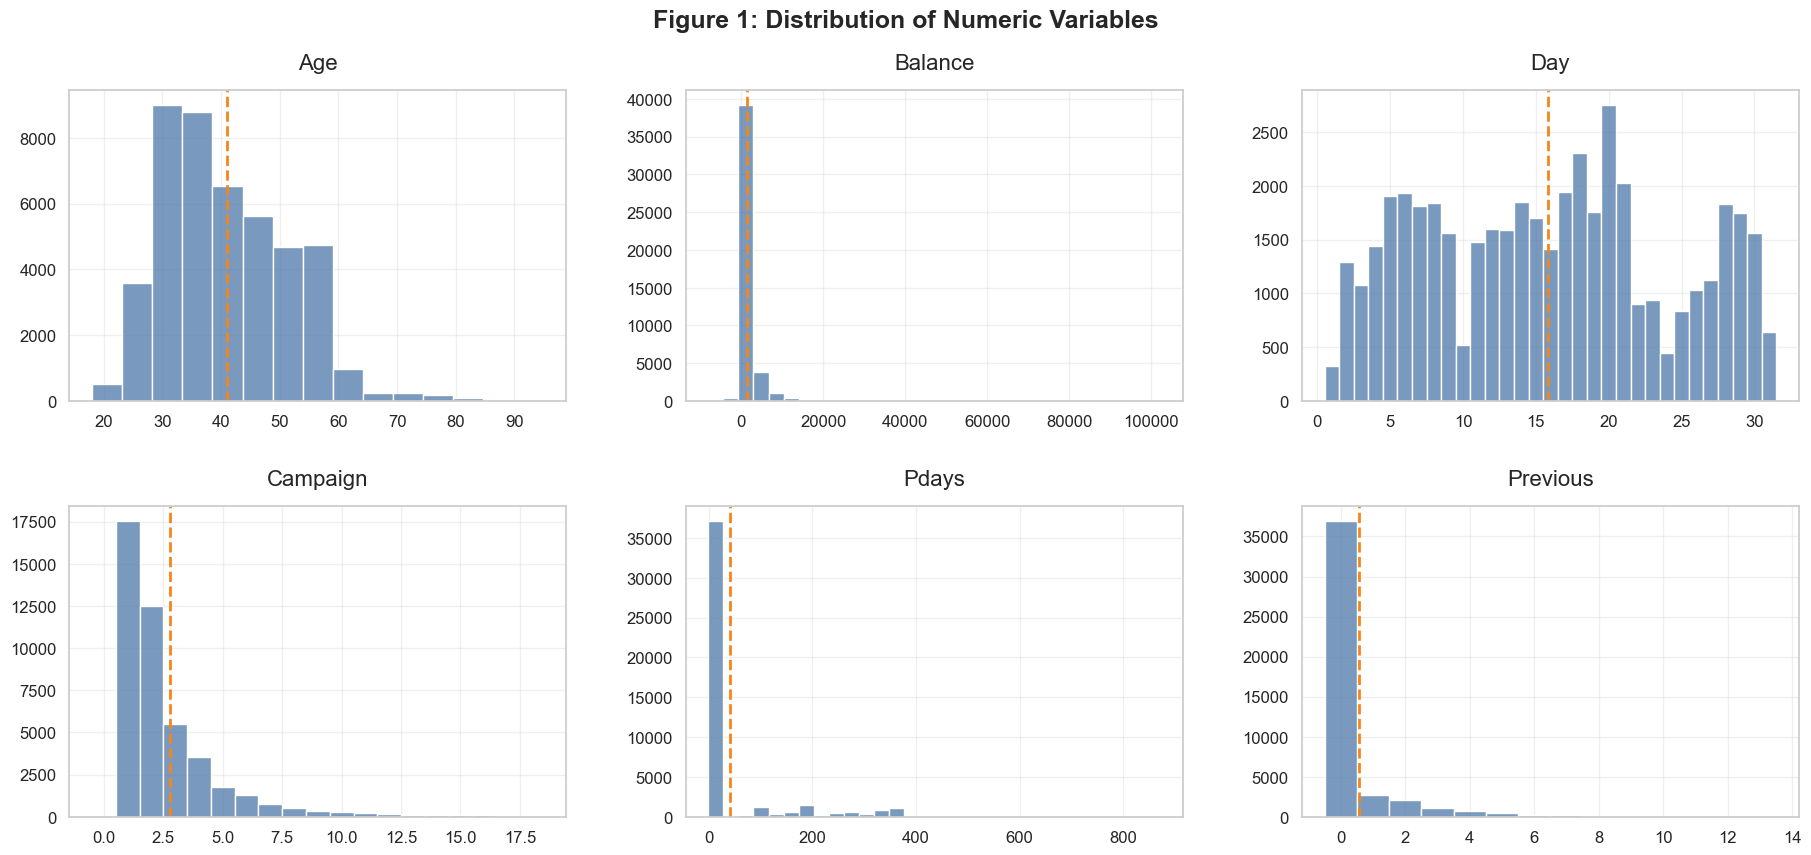

In [9]:
# Numeric Variable Distributions
numeric_features = [
    'age', 'balance', 'day', 'campaign', 'pdays', 'previous'
]

custom_bins = {
    'age': 15,
    'balance': 30,
    'day': np.arange(1, 33) - 0.5,
    'campaign': np.arange(0, 20) - 0.5,
    'pdays': 30,
    'previous': np.arange(0, 15) - 0.5
}

sns.set_theme(style = 'whitegrid')

n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize = (6*n_cols, 4*n_rows),
    constrained_layout = True
)

fig.set_constrained_layout_pads(
    hspace = 0.10,
    wspace = 0.10
)

axes = axes.flatten()

for i, var in enumerate(numeric_features):

    sns.histplot(
        df[var],
        bins = custom_bins[var],
        color = '#4C78A8',
        edgecolor = 'white',
        linewidth = 1,
        ax=axes[i]
    )

    mean_val = df[var].mean()
    axes[i].axvline(
        mean_val,
        color = '#F58518',
        linestyle = '--',
        linewidth = 2
    )

    axes[i].set_title(var.replace('_', ' ').title(), fontsize = 16, pad = 15)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis = 'both', labelsize = 12)
    axes[i].grid(True, alpha = 0.3)

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Figure 1: Distribution of Numeric Variables',
    fontsize = 18,
    fontweight = 'bold',
    y = 1.05
)

plt.show()


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Numeric Variable Distributions by Term Deposit Subscription.
</span>
Boxplots comparing the distributions of numeric variables between customers who did not subscribe to a term deposit (y = "no") and those who did (y = "yes") are shown in <b>Figure 2</b>. Several variables show noticeable differences between the two groups. Subscribers tend to have slightly higher account balances on average, although the balance distribution is highly right-skewed with considerable variability due to several large outliers. Campaign-related variables reveal additional patterns, as <code>campaign</code> tends to be lower among subscribers, suggesting that successful outcomes often occur after relatively few contact attempts. The variable <code>previous</code> appears slightly higher among subscribers, while <code>pdays</code> shows substantial dispersion with many small values, indicating that more recent prior contact may be associated with successful outcomes. In contrast, <code>day</code> displays similar distributions across both groups, suggesting that the timing of contact within the month is not strongly related to subscription outcomes.


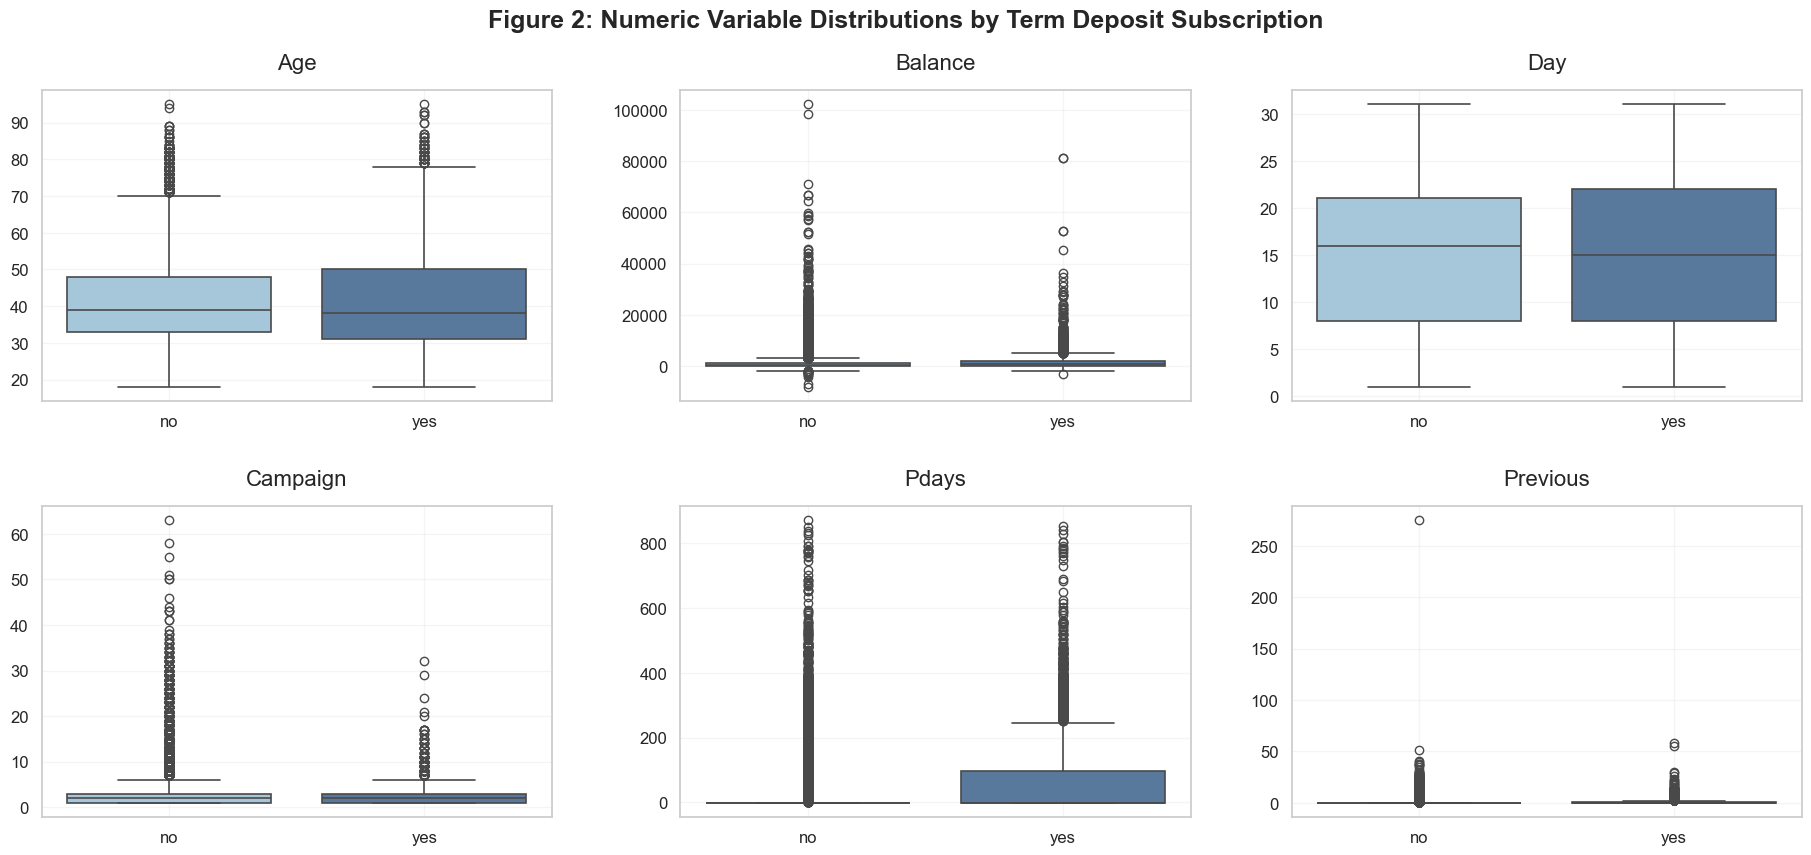

In [10]:
# Boxplots: Numeric Variables vs Target (Term Deposit Subscription)
numeric_features = [
    'age', 'balance', 'day', 'campaign', 'pdays', 'previous'
]

sns.set_theme(style = 'whitegrid')

n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize = (6*n_cols, 4*n_rows),
    constrained_layout = True
)

fig.set_constrained_layout_pads(
    hspace = 0.10,
    wspace = 0.10
)

axes = axes.flatten()

for i, var in enumerate(numeric_features):

    sns.boxplot(
        x = 'y',
        y = var,
        hue = 'y',
        data = df,
        palette = ['#9ecae1','#4C78A8'],
        linewidth = 1.2,
        ax = axes[i],
        legend = False
    )

    axes[i].set_title(
        var.replace('_', ' ').title(),
        fontsize = 16,
        pad = 15
    )

    axes[i].set_ylabel('')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis = 'both', labelsize = 12)

    axes[i].set_axisbelow(True)
    axes[i].grid(True, alpha = 0.2)

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Figure 2: Numeric Variable Distributions by Term Deposit Subscription',
    fontsize = 18,
    fontweight = 'bold',
    y = 1.05
)

plt.show()


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Correlation Analysis.
</span>
<span style="color:#1f4ed8; font-style:italic; font-weight:600;">Correlation Analysis.</span>
To further examine relationships among the numeric variables, a correlation matrix was computed for <code>age</code>, <code>balance</code>, <code>day</code>, <code>campaign</code>, <code>pdays</code>, and <code>previous</code>, along with the binary <code>subscription</code> indicator (see <b>Figure 3</b>). Overall, pairwise correlations are weak, suggesting limited multicollinearity and indicating that the variables capture largely distinct aspects of customer characteristics and marketing activity. The strongest relationship appears between <code>pdays</code> and <code>previous</code> (0.45), while other associations, such as <code>day</code> and <code>campaign</code> (0.16) and <code>age</code> and <code>balance</code> (0.10), are comparatively small. Correlations with the subscription outcome are also weak, with the largest values observed for <code>pdays</code> (0.10) and <code>previous</code> (0.09).


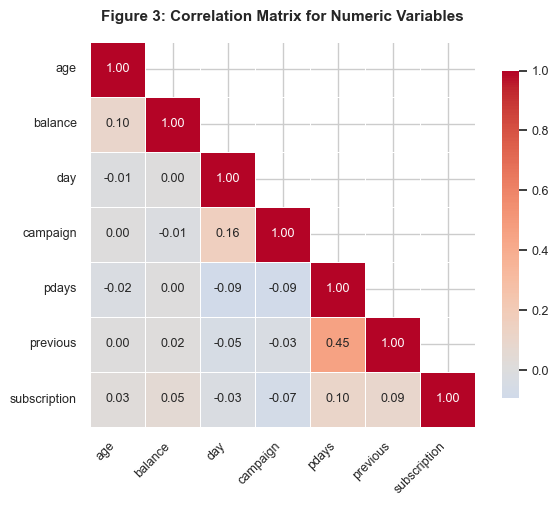

In [11]:
# Correlation Analysis
numeric_vars = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

sns.set_theme(style = 'whitegrid')

corr_df = df[numeric_vars].copy()
corr_df['subscription'] = (df['y'] == 'yes').astype(int)

corr_matrix = corr_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype = bool), k = 1)

plt.figure(figsize = (7, 5))

ax = sns.heatmap(
    corr_matrix,
    mask = mask,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    center = 0,
    square = True,
    linewidths = 0.5,
    annot_kws = {'size': 9},
    cbar_kws = {'shrink': 0.85}
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize = 9)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation = 45,
    ha = 'right',
    fontsize = 9
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation = 0,
    fontsize = 9
)

ax.set_axisbelow(True)

plt.title(
    'Figure 3: Correlation Matrix for Numeric Variables',
    fontsize = 11,
    fontweight = 'bold',
    pad = 15
)

plt.show()


### Categorical Variable Analysis

In addition to the numeric variables examined previously, the dataset includes nine categorical variables describing customer demographics, financial characteristics, and marketing campaign attributes. **Table 2** summarizes these variables, including the number of categories and the proportion of missing observations. The categorical features range from binary indicators such as `default` and `housing` to variables with multiple categories such as `job` and `month`.


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Categorical Variable Distributions.
</span>
As shown in <b>Figure 4</b>, the categorical variables display varying degrees of class imbalance. The <code>job</code> variable includes twelve occupational groups, with blue-collar, management, and technician roles representing the largest shares, while categories such as student and unknown appear infrequently. The <code>marital</code> variable is dominated by married customers, and <code>education</code> is concentrated in the secondary category. Several binary indicators are also highly imbalanced: <code>default</code> is overwhelmingly “no,” housing loans are relatively common, and personal loans are less prevalent. Most marketing contacts occurred via cellular communication, and campaign activity was concentrated in late spring and summer, particularly May. The variable <code>poutcome</code> is heavily dominated by the unknown category, indicating that many customers had no recorded prior campaign outcome.


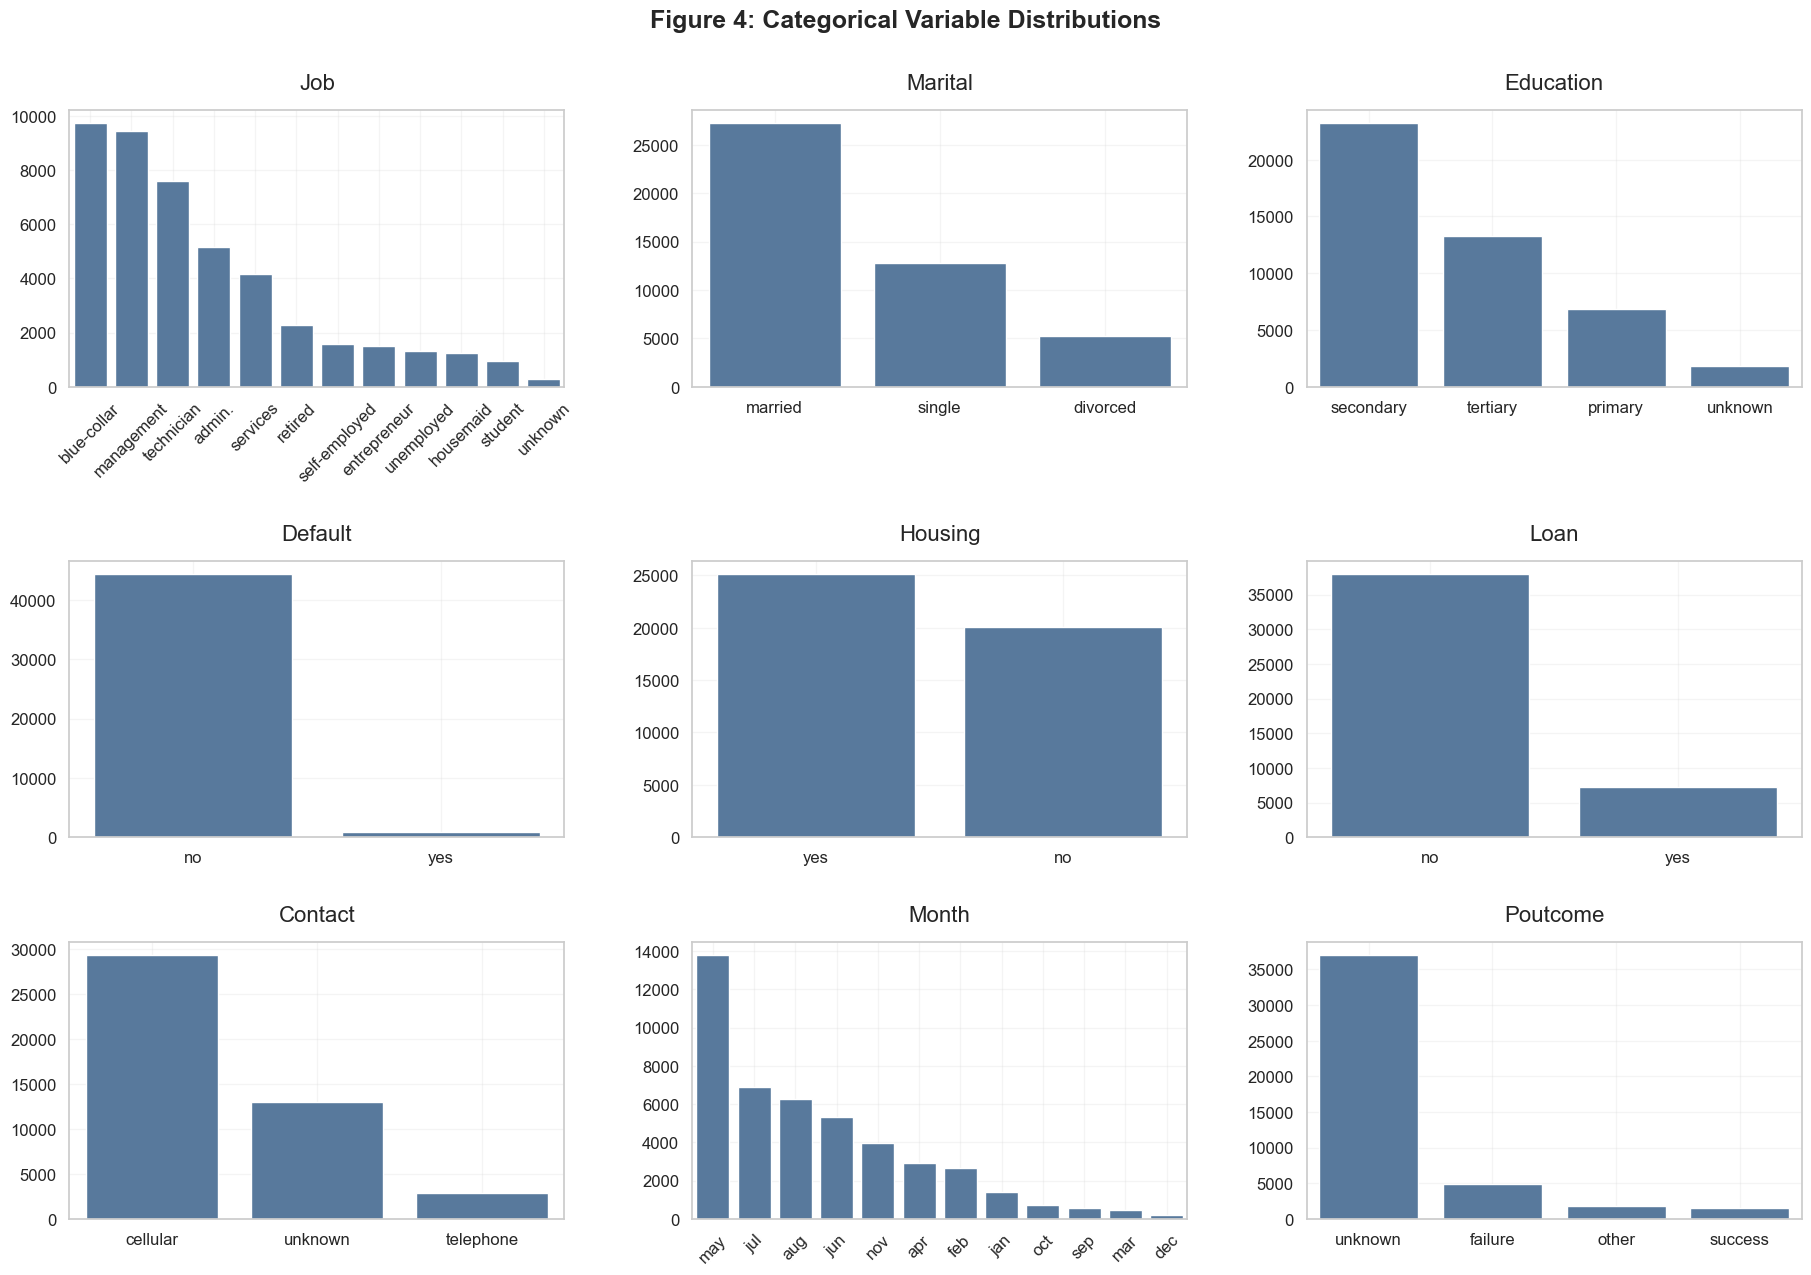

In [12]:
# Overall Categorical Variable Distributions
categorical_features = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'poutcome'
]

sns.set_theme(style = 'whitegrid')

n_cols = 3
n_rows = int(np.ceil(len(categorical_features) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize = (6*n_cols, 4*n_rows),
    constrained_layout = True
)

fig.set_constrained_layout_pads(
    hspace = 0.10,
    wspace = 0.10
)

axes = axes.flatten()

for i, var in enumerate(categorical_features):

    sns.countplot(
        x = df[var],
        ax = axes[i],
        order = df[var].value_counts().index,
        color = '#4C78A8',
        edgecolor = 'white',
        linewidth = 1
    )

    axes[i].set_title(
        var.replace('_', ' ').title(),
        fontsize = 16,
        pad = 15
    )

    axes[i].set_ylabel('')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis = 'both', labelsize = 12)

    if df[var].nunique() > 4:
        axes[i].tick_params(axis = 'x', rotation = 45)

    axes[i].set_axisbelow(True)
    axes[i].grid(True, alpha = 0.2)

for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Figure 4: Categorical Variable Distributions',
    fontsize = 18,
    fontweight = 'bold',
    y = 1.05
)

plt.show()


Examining the categorical distributions reveals notable class imbalance for several variables, particularly `default`, `contact`, and `poutcome`, while others such as `job`, `education`, and `month` show more diverse category frequencies. These patterns provide context for subsequent analysis of how category membership relates to subscription outcomes.


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Categorical Variable Distributions by Term Deposit Subscription.
</span>
<b>Figure 5</b> compares subscription proportions across categories. The strongest association appears for <code>poutcome</code>, where customers with a previous campaign outcome of “success” show a much higher subscription rate (approximately 65%) than those in the failure, other, or unknown categories. More moderate differences appear for other variables. <code>Contact</code> shows higher subscription rates for cellular contacts, while <code>education</code> and <code>job</code> categories display smaller differences, with students and retired customers exhibiting somewhat higher subscription proportions. Temporal variation is also visible in <code>month</code>, suggesting possible seasonality in campaign effectiveness. In contrast, variables such as <code>marital</code>, <code>default</code>, <code>housing</code>, and <code>loan</code> show relatively small differences across categories.

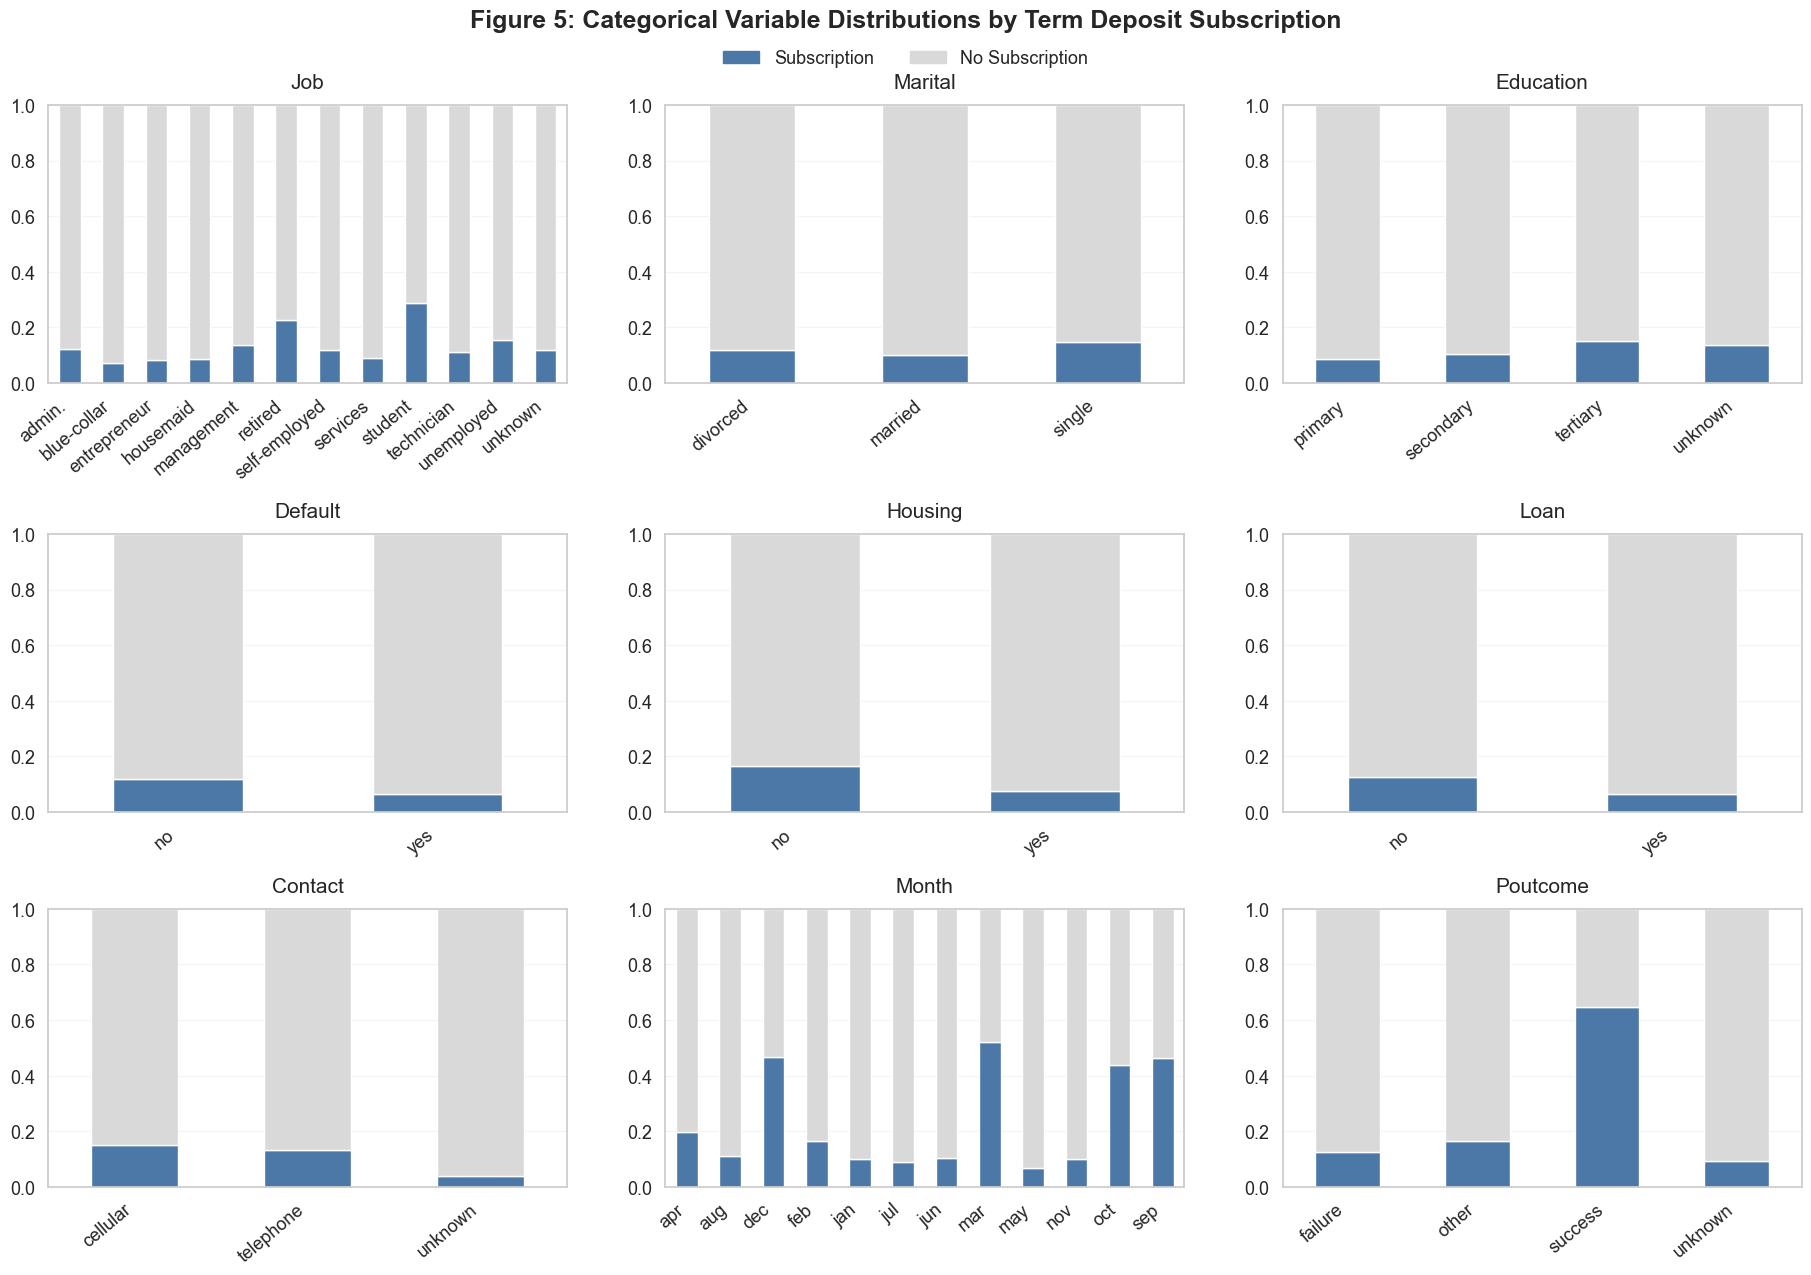

In [13]:
# Row-Normalized Crosstabs for All Categorical Predictors
sns.set_theme(style = 'whitegrid')

categorical_features = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'poutcome'
]

n_cols = 3
n_rows = int(np.ceil(len(categorical_features) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize = (6*n_cols, 4*n_rows),
    constrained_layout = True
)

fig.set_constrained_layout_pads(
    hspace = 0.05,
    wspace = 0.10
)

axes = axes.flatten()

for i, var in enumerate(categorical_features):

    ct = pd.crosstab(df[var], df['y'], normalize = 'index')
    ct = ct[['yes', 'no']]

    ct.plot(
        kind = 'bar',
        stacked = True,
        ax = axes[i],
        color = ['#4C78A8', '#D9D9D9'],  # yes = blue | no = grey
        edgecolor = 'white',
        linewidth = 1
    )

    axes[i].set_title(
        var.replace('_', ' ').title(),
        fontsize = 15,
        pad = 12
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_ylim(0, 1)
    
    axes[i].tick_params(axis = 'y', labelsize = 13)
    axes[i].set_xticklabels(
        axes[i].get_xticklabels(),
        rotation = 40,
        ha = 'right',
        fontsize = 13,
        fontweight = 'normal'
    )  
    
    axes[i].set_axisbelow(True)
    axes[i].grid(True, alpha = 0.2)
    axes[i].legend_.remove()

for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

fig.legend(
    handles = [
        plt.Rectangle((0, 0), 1, 1, color = '#4C78A8'),
        plt.Rectangle((0, 0), 1, 1, color = '#D9D9D9')
    ],
    labels = ['Subscription', 'No Subscription'],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.03),
    ncol = 2,
    frameon = False,
    fontsize = 13
)

fig.suptitle(
    'Figure 5: Categorical Variable Distributions by Term Deposit Subscription',
    fontsize = 18,
    fontweight = 'bold',
    y = 1.05
)

plt.show()


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Categorical Variable Encoding.
</span>
Binary variables including <code>default</code>, <code>housing</code>, <code>loan</code>, and the target variable <code>y</code> were encoded using values of 1 for “yes” and 0 for “no.” Multicategory variables such as <code>job</code>, <code>marital</code>, <code>education</code>, <code>contact</code>, <code>month</code>, and <code>poutcome</code> were transformed using one-hot encoding, in which each category is represented by a binary indicator variable. To avoid perfect multicollinearity, one category from each variable was omitted during encoding. See <b>Table 3</b> for a summary of the resulting indicator variables.


In [14]:
# Categorical Variable Encoding
df_model = df.copy()

# Binary Categorical Variables
binary_vars = ['default', 'housing', 'loan', 'y']

for col in binary_vars:
    df_model[col] = df_model[col].map({'yes': 1, 'no': 0})

# One-Hot Encoding
categorical_vars = [
    'job',
    'marital',
    'education',
    'contact',
    'month',
    'poutcome'
]

df_model = pd.get_dummies(
    df_model,
    columns = categorical_vars,
    drop_first = True
)

display(HTML(f"""<br>
    Final Dataset Shape:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {df_model.shape}
    </span>
"""))

def get_encoded(prefix):
    return ', '.join(sorted([c for c in df_model.columns if c.startswith(prefix)]))

# Encoding summary table
encoding_summary = pd.DataFrame({
    'Variable': [
        'default',
        'housing',
        'loan',
        'y',
        'job',
        'marital',
        'education',
        'contact',
        'month',
        'poutcome'
    ],
    'Encoding': [
        '0 = no, 1 = yes',
        '0 = no, 1 = yes',
        '0 = no, 1 = yes',
        '0 = no, 1 = yes',
        get_encoded('job_'),
        get_encoded('marital_'),
        get_encoded('education_'),
        get_encoded('contact_'),
        get_encoded('month_'),
        get_encoded('poutcome_')
    ]
})

display(HTML('<br><b>Table 3: Encoded Categorical Variables</b>'))

display(
    encoding_summary
        .style
        .hide(axis = 'index')
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'left')]}
        ])
)


Variable,Encoding
default,"0 = no, 1 = yes"
housing,"0 = no, 1 = yes"
loan,"0 = no, 1 = yes"
y,"0 = no, 1 = yes"
job,"job_blue-collar, job_entrepreneur, job_housemaid, job_management, job_retired, job_self-employed, job_services, job_student, job_technician, job_unemployed, job_unknown"
marital,"marital_married, marital_single"
education,"education_secondary, education_tertiary, education_unknown"
contact,"contact_telephone, contact_unknown"
month,"month_aug, month_dec, month_feb, month_jan, month_jul, month_jun, month_mar, month_may, month_nov, month_oct, month_sep"
poutcome,"poutcome_other, poutcome_success, poutcome_unknown"


## Methods: Classification Models

This section describes the classification methods used to predict whether a customer subscribes to a term deposit. A <b>logistic regression model is used as the baseline classifier</b> because it is a widely applied and interpretable method for binary outcome prediction. To evaluate whether more flexible machine learning approaches improve predictive accuracy, two ensemble methods are also implemented: <b>random forest</b> and <b>gradient boosting</b>. Random forest constructs a collection of decision trees using bootstrap samples of the training data and random subsets of predictors at each split, while boosting builds a sequence of shallow trees that iteratively focus on correcting the errors of previous models. All models are trained on the training set and tuning parameters for the ensemble methods are selected using cross-validation applied only to the training data. Performance is evaluated using misclassification error on a hold-out test set to allow consistent comparison between the logistic regression baseline and the ensemble approaches.


### Training/Test Split

To evaluate model performance on unseen data, the processed dataset was divided into training and testing samples using a stratified train–test split. In this approach, 70% of the observations were assigned to the training set and the remaining 30% were reserved for testing. Stratification preserved the class distribution of the target variable across both samples, ensuring that the proportion of customers who subscribed to a term deposit remained consistent between the two datasets. The training set contains 31,647 observations and the test set contains 13,564 observations, with each dataset including 41 predictor variables after preprocessing. The class distribution is nearly identical across the two samples, with approximately 88.3% of observations belonging to class 0 (did not subscribe) and about 11.7% belonging to class 1 (subscribed). The training set was used for model estimation and parameter tuning, while the test set was reserved exclusively for evaluating predictive performance.


In [15]:
# Training/Test Split
X = df_model.drop(columns = ['y'])
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 7, stratify = y)

summary_df = pd.DataFrame({
    'dataset': ['training', 'test'],
    'observations': [X_train.shape[0], X_test.shape[0]],
    'features': [X_train.shape[1], X_test.shape[1]],
    'prop_y0': [
        (y_train == 0).mean(),
        (y_test == 0).mean()
    ],
    'prop_y1': [
        (y_train == 1).mean(),
        (y_test == 1).mean()
    ]
})

display(summary_df)


,dataset,observations,features,prop_y0,prop_y1
0,training,31647,41,0.883022,0.116978
1,test,13564,41,0.882999,0.117001


### Feature Standardization

Prior to model estimation, numeric predictor variables were standardized so that each variable has mean zero and unit variance. The scaling parameters were estimated using the training dataset only and subsequently applied to the test dataset. This approach prevents information from the test set from influencing the model training process and ensures that predictors measured on different scales contribute comparably during model estimation.


In [16]:
# Predictor Standardization
y_binary = (df['y'] == 'yes').astype(int)
X = df.drop(columns = ['y'])
y = y_binary

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Baseline: Logistic Regression Model

Logistic regression provides an interpretable baseline that serves as a benchmark against which the performance of the ensemble methods can be compared. This method models the probability of a binary outcome as a logistic function of the predictor variables, allowing the log-odds of subscription to be expressed as a linear combination of the predictors. It is widely used in classification problems due to its interpretability and relatively simple model structure. 


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Hyperparameter Selection.
</span>
Hyperparameter tuning for the logistic regression model was conducted using grid search with seven-fold cross-validation on the training data. The regularization parameter C, which controls the strength of the L_2 penalty, was evaluated over the grid {0.01, 0.1, 1, 10, 100}. Smaller values of C correspond to stronger regularization, which can help prevent overfitting, while larger values allow the model greater flexibility by reducing the degree of shrinkage applied to the coefficients. The L_2 penalty was selected because it performs coefficient shrinkage without eliminating predictors, helping produce stable coefficient estimates and mitigating multicollinearity among correlated variables. Model selection was based on the average area under the receiver operating characteristic curve (AUC) across the cross-validation folds. The grid search identified C=0.01with an L_2 penalty as the optimal configuration, indicating that relatively strong regularization produced the best cross-validated predictive performance.


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Model Performance.
</span>
The model is estimated using the training dataset with standardized numeric predictors, and performance is evaluated using misclassification error, AUC, and confusion matrices computed on both the training and test datasets. The logistic regression model achieves a training accuracy of 0.8918 (error = 0.1082) with a training AUC of 0.7656. On the test dataset, the model achieves an accuracy of 0.8931 (error = 0.1069) with a test AUC of 0.7733. The similarity between training and test performance indicates that the model generalizes well and does not exhibit substantial overfitting. The training and test confusion matrices show that the model correctly classifies the majority of non-subscription outcomes, although a relatively large number of false negatives remain, reflecting the class imbalance present in the dataset.


In [17]:
# Baseline: Logistic Regression Model
param_grid = {
    'C':[0.01, 0.1, 1, 10, 100],
    'penalty':['l2']
}

logit = LogisticRegression(solver = 'lbfgs', max_iter = 5000)

# Grid Search w/7-Fold CV
grid = GridSearchCV(
    estimator = logit,
    param_grid = param_grid,
    cv = 7,
    scoring = 'roc_auc',
    n_jobs = 6
)

grid.fit(X_train_scaled, y_train)

logit_model = grid.best_estimator_

# Training Performance
y_train_pred = logit_model.predict(X_train_scaled)
y_train_prob = logit_model.predict_proba(X_train_scaled)[:,1]

train_cm = confusion_matrix(y_train, y_train_pred)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_error = 1 - train_accuracy
train_auc = roc_auc_score(y_train, y_train_prob)

display(HTML(f"""
    <br><b>Training Performance</b><br>

    Accuracy:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_accuracy:.4f}
    </span><br>

    Error:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_error:.4f}
    </span><br>

    AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_auc:.4f}
    </span><br>
"""))

display_confusion_matrix(train_cm, 'Confusion Matrix')


,Predicted 0,Predicted 1
Actual 0,27588,357
Actual 1,3067,635


In [18]:
# Selected Hyperparameters
display(HTML(f"""
    <br><b>Selected Hyperparameters</b><br>
    Best C:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid.best_params_['C']}
    </span><br>

    Best Penalty:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid.best_params_['penalty']}
    </span><br>
"""))


In [19]:
# Test Performance
y_test_pred = logit_model.predict(X_test_scaled)
y_test_prob = logit_model.predict_proba(X_test_scaled)[:,1]

test_cm = confusion_matrix(y_test, y_test_pred)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_error = 1 - test_accuracy
test_auc = roc_auc_score(y_test, y_test_prob)

display(HTML(f"""
    <br><b>Test Performance</b><br>

    Accuracy:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_accuracy:.4f}
    </span><br>

    Error:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_error:.4f}
    </span><br>

    AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_auc:.4f}
    </span><br>
"""))

display_confusion_matrix(test_cm, 'Confusion Matrix')


,Predicted 0,Predicted 1
Actual 0,11820,157
Actual 1,1293,294


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Coefficient Estimates.
</span>
Inspection of the estimated coefficients highlights several predictors strongly associated with subscription probability, as illustrated in <b>Figure 6</b>, which displays the ten largest coefficients by absolute magnitude. The largest coefficient in absolute value corresponds to <code>contact_unknown</code>, followed by <code>poutcome_success</code>, indicating that contact method and prior campaign outcomes play an important role in predicting client responses. Other influential predictors include <code>campaign</code>, <code>housing</code>, and several <code>month</code> indicators such as <code>month_aug</code>, <code>month_nov</code>, <code>month_jul</code>, <code>month_may</code>, and <code>month_jan</code>, suggesting that both campaign intensity and seasonal timing are associated with variation in subscription likelihood. Overall, the coefficient magnitudes shown in <b>Figure 6</b> indicate that prior marketing outcomes and contact patterns are among the most informative predictors of client response. See <b>Appendix A</b> <span style="color:gray;">(Table A2)</span> for detailed feature importance rankings.


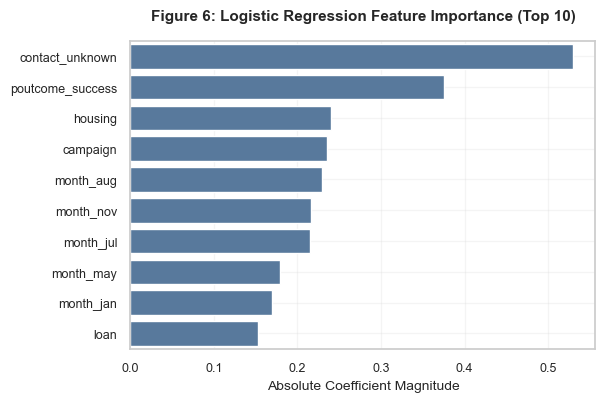

Feature,Coefficient
contact_unknown,-0.530217
poutcome_success,0.375985
housing,-0.239590
campaign,-0.235312
month_aug,-0.229112
month_nov,-0.216643
month_jul,-0.214380
month_may,-0.178654
month_jan,-0.168933
loan,-0.152756


In [20]:
# Logistic Regression Feature Importance
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logit_model.coef_[0]
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    by = 'Abs_Coefficient',
    ascending = False
)

coef_disp = coef_df.drop(columns = ['Abs_Coefficient']).round(6)

# Plot: Feature Importance
sns.set_theme(style = 'whitegrid')

plt.figure(figsize = (6, 4))

ax = sns.barplot(
    data = coef_df.head(10),
    x = 'Abs_Coefficient',
    y = 'Feature',
    color = '#4C78A8',
    edgecolor = 'white',
    linewidth = 1
)

ax.set_xlabel('Absolute Coefficient Magnitude', fontsize = 10)
ax.set_ylabel('')

ax.tick_params(axis = 'both', labelsize = 9)

ax.set_axisbelow(True)
ax.grid(True, alpha = 0.2)

plt.title(
    'Figure 6: Logistic Regression Feature Importance (Top 10)',
    fontsize = 11,
    fontweight = 'bold',
    pad = 15
)

plt.show()

display(HTML('<br><b>Table A1: Logistic Regression Feature Importance (Top 10)</b>'))
display(
    coef_disp.head(10)
        .style
        .hide(axis = 'index')
        .set_properties(subset = ['Feature'], **{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th.col_heading.level0.col0',
             'props': [('text-align', 'left')]}
        ])
)


The logistic regression model provides a useful, interpretable baseline that captures meaningful relationships between customer characteristics, marketing history, and subscription behavior while achieving stable predictive performance across the training and test datasets. 


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Model Diagnostics & Dimensionality Considerations.
</span>
Dimensionality reduction and regularization techniques were considered after fitting the baseline logistic regression model. However, correlation analysis indicated limited multicollinearity among predictors, and model performance was similar across the training and test datasets, suggesting minimal overfitting. Consequently, dimensionality reduction methods such as principal component analysis were not pursued, allowing the model to retain interpretability while maintaining stable predictive performance.


### Random Forest Model

Random forests are an ensemble learning method that improves predictive performance by aggregating a large number of decision trees. Each tree is trained on a bootstrap sample of the training data, and at each split a random subset of predictors is considered. This randomization reduces correlation among individual trees and improves the stability and accuracy of the aggregated predictions. Final classifications are obtained through majority voting across all trees in the forest.


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Hyperparameter Selection.
</span>
Hyperparameter tuning for the random forest model was conducted using grid search with five-fold cross-validation on the training data. The tuning process evaluated key parameters controlling ensemble size and tree complexity, including the number of trees (<code>n_estimators</code>), the number of predictors considered at each split (<code>max_features</code>), the maximum tree depth (<code>max_depth</code>), and the minimum number of observations required in a terminal node (<code>min_samples_leaf</code>). Model selection was based on the average area under the receiver operating characteristic curve (AUC) across the cross-validation folds. The grid search identified an optimal configuration of 500 trees with <code>max_features = sqrt</code>, <code>max_depth = None</code>, and <code>min_samples_leaf = 5</code>, indicating that restricting terminal node size while allowing trees to grow flexibly provided the most reliable predictive performance on the training data.


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Model Performance.
</span>
The random forest model is trained using the training dataset, and performance is evaluated using misclassification error, AUC, and confusion matrices computed on both the training and test datasets. The model achieves a training accuracy of 0.9065 (error = 0.0935) with a training AUC of 0.9457, indicating strong in-sample predictive performance. On the test dataset, the model achieves an accuracy of 0.8959 (error = 0.1041) with a test AUC of 0.7999, representing a modest improvement relative to the logistic regression baseline. The test confusion matrix indicates improved identification of subscription outcomes while maintaining strong performance for non-subscription predictions, although some false negatives remain due to the class imbalance present in the dataset. The relatively small difference between training and test performance suggests that the random forest model generalizes well and does not exhibit substantial overfitting despite its greater flexibility.


In [21]:
# Random Forest Model
param_grid_rf = {
    'n_estimators': [200, 500],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5]
}

rf = RandomForestClassifier(random_state = 7, n_jobs = 6)

# Grid Search (7-Fold CV)
grid_rf = GridSearchCV(
    estimator = rf,
    param_grid = param_grid_rf,
    cv = 7,
    scoring = 'roc_auc',
    n_jobs = 6
)

grid_rf.fit(X_train, y_train)

rf_model = grid_rf.best_estimator_


/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [22]:
# Training Performance
y_train_pred_rf = rf_model.predict(X_train)
y_train_prob_rf = rf_model.predict_proba(X_train)[:,1]

train_cm_rf = confusion_matrix(y_train, y_train_pred_rf)

train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_error_rf = 1 - train_accuracy_rf
train_auc_rf = roc_auc_score(y_train, y_train_prob_rf)

display(HTML(f"""
    <br><b>Training Performance</b><br>

    Accuracy:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_accuracy_rf:.4f}
    </span><br>

    Error:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_error_rf:.4f}
    </span><br>

    AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_auc_rf:.4f}
    </span><br>
"""))

display_confusion_matrix(train_cm_rf, 'Confusion Matrix')


,Predicted 0,Predicted 1
Actual 0,27784,161
Actual 1,2797,905


In [23]:
# Selected Hyperparameters
display(HTML(f"""
    <br><b>Selected Hyperparameters</b><br>
    
    n_estimators: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_rf.best_params_['n_estimators']}<br>
    </span>
        
    max_features: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_rf.best_params_['max_features']}<br>
    </span>
        
    max_depth: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_rf.best_params_['max_depth']}<br>
    </span>
        
    min_samples_leaf: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_rf.best_params_['min_samples_leaf']}
    </span><br>
        
"""))


In [31]:
# Test Performance
y_test_pred_rf = rf_model.predict(X_test)
y_test_prob_rf = rf_model.predict_proba(X_test)[:,1]

test_cm_rf = confusion_matrix(y_test, y_test_pred_rf)

test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_error_rf = 1 - test_accuracy_rf
test_auc_rf = roc_auc_score(y_test, y_test_prob_rf)

display(HTML(f"""
    <br><b>Test Performance</b><br>

    Accuracy:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_accuracy_rf:.4f}
    </span><br>

    Error:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_error_rf:.4f}
    </span><br>

    AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_auc_rf:.4f}
    </span><br>
"""))

display_confusion_matrix(test_cm_rf, 'Confusion Matrix')


,Predicted 0,Predicted 1
Actual 0,11850,127
Actual 1,1285,302


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Feature Importance.
</span>
Random forest feature importance measures highlight the predictors most influential for classification, as illustrated in <b>Figure 7</b>, which displays the ten most important predictors. The most influential predictor is <code>poutcome_success</code>, indicating that prior successful marketing outcomes strongly increase the likelihood of subscription. Client characteristics such as <code>age</code> and <code>balance</code> also rank among the most important predictors, suggesting that demographic and financial attributes play an important role in determining subscription behavior. Additional influential variables include <code>day</code> and <code>pdays</code>, which capture aspects of contact timing and recency. Several campaign-related variables, including <code>previous</code>, <code>campaign</code>, and <code>contact_unknown</code>, also contribute to predictive performance, reflecting the importance of prior marketing interactions. The importance rankings shown in <b>Figure 7</b> suggest that both client financial characteristics and historical marketing engagement are key drivers of term deposit subscription behavior. See <b>Appendix A</b> <span style="color:gray;">(Table A2)</span> for detailed feature importance rankings.


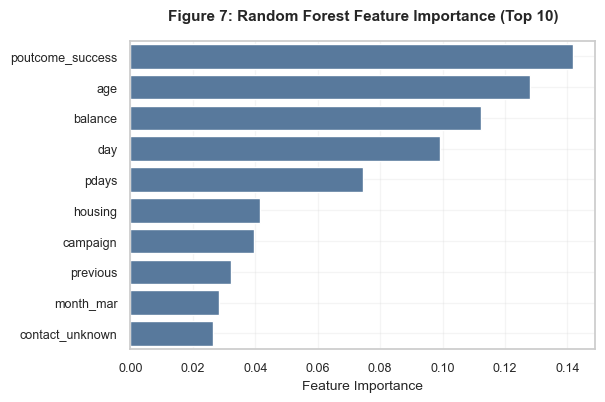

Feature,Importance
poutcome_success,0.141891
age,0.127929
balance,0.112303
day,0.099265
pdays,0.074667
housing,0.041402
campaign,0.039602
previous,0.032324
month_mar,0.028342
contact_unknown,0.026421


In [24]:
# Feature Importance
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by = 'Importance', ascending = False)

importance_df = importance_df.round(6)

# Plot: Feature Importance
sns.set_theme(style = 'whitegrid')

plt.figure(figsize = (6, 4))

ax = sns.barplot(
    data = importance_df.head(10),
    x = 'Importance',
    y = 'Feature',
    color = '#4C78A8',
    edgecolor = 'white',
    linewidth = 1
)

ax.set_xlabel('Feature Importance', fontsize = 10)
ax.set_ylabel('')

ax.tick_params(axis = 'both', labelsize = 9)

ax.set_axisbelow(True)
ax.grid(True, alpha = 0.2)

plt.title(
    'Figure 7: Random Forest Feature Importance (Top 10)',
    fontsize = 11,
    fontweight = 'bold',
    pad = 15
)

plt.show()

display(HTML('<br><b>Table A2: Random Forest Feature Importance (Top 10)</b>'))
display(
    importance_df.head(10)
        .style
        .hide(axis = 'index')
        .set_properties(subset = ['Feature'], **{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th.col_heading.level0.col0',
             'props': [('text-align', 'left')]}
        ])
)


The random forest model captures nonlinear relationships and interactions among predictors, providing a modest improvement in predictive performance relative to the logistic regression baseline. The model achieves higher AUC while maintaining similar classification accuracy on the test dataset. To assess whether further gains in predictive performance are possible, the analysis next evaluates a boosting-based ensemble method.


### Gradient Boosting Model

Gradient boosting is an ensemble learning method that builds a sequence of decision trees in which each new tree is trained to correct the errors made by the previous trees. Rather than constructing trees independently, boosting fits trees sequentially so that observations that are more difficult to classify receive greater emphasis in later iterations. This iterative process allows the model to capture complex nonlinear relationships and interactions among predictors while progressively improving predictive accuracy.


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Hyperparameter Selection.
</span>
Hyperparameter tuning for the gradient boosting model was conducted using grid search with five-fold cross-validation on the training data. The tuning process evaluated key parameters controlling the structure and learning behavior of the boosted ensemble, including the number of trees (<code>n_estimators</code>), the learning rate (<code>learning_rate</code>), the maximum tree depth (<code>max_depth</code>), and the minimum number of observations in terminal nodes (<code>min_samples_leaf</code>). Model selection was based on the average area under the receiver operating characteristic curve (AUC) across the cross-validation folds. The grid search identified an optimal configuration of 200 trees, with <code>learning_rate = 0.1</code>, <code>max_depth = 4</code>, and <code>min_samples_leaf = 1</code>, indicating that moderately shallow trees with a standard learning rate provided the most reliable predictive performance on the training data.


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Model Performance.
</span>
The gradient boosting model was trained on the training dataset and evaluated using misclassification error, AUC, and confusion matrices for both the training and test datasets. The model achieves a training accuracy of 0.9092 (error = 0.0908) with a training AUC of 0.8359, indicating strong in-sample predictive performance. On the test dataset, the model achieves an accuracy of 0.8954 (error = 0.1046) with a test AUC of 0.8058, the highest among the models considered. The confusion matrix indicates improved identification of positive subscription outcomes relative to logistic regression while maintaining strong performance for non-subscription predictions, although some false negatives remain due to class imbalance in the dataset.


In [25]:
# Gradient Boosting Model
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_leaf': [1, 5]
}

gb = GradientBoostingClassifier(random_state = 7)

# Grid Search (7-Fold CV)
grid_gb = GridSearchCV(
    estimator = gb,
    param_grid = param_grid_gb,
    cv = 7,
    scoring = 'roc_auc',
    n_jobs = 6
)

grid_gb.fit(X_train, y_train)

gb_model = grid_gb.best_estimator_


In [26]:
# Training Performance
y_train_pred_gb = gb_model.predict(X_train)
y_train_prob_gb = gb_model.predict_proba(X_train)[:,1]

train_cm_gb = confusion_matrix(y_train, y_train_pred_gb)

train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
train_error_gb = 1 - train_accuracy_gb
train_auc_gb = roc_auc_score(y_train, y_train_prob_gb)

display(HTML(f"""
    <br><b>Training Performance</b><br>

    Accuracy:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_accuracy_gb:.4f}
    </span><br>

    Error:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_error_gb:.4f}
    </span><br>

    AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_auc_gb:.4f}
    </span><br>
"""))

display_confusion_matrix(train_cm_gb, 'Confusion Matrix')


,Predicted 0,Predicted 1
Actual 0,27636,309
Actual 1,2564,1138


In [27]:
# Selected Hyperparameters
display(HTML(f"""
    <br><b>Selected Hyperparameters</b><br>

    n_estimators: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_gb.best_params_['n_estimators']}<br>
    </span>
    
    learning_rate: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_gb.best_params_['learning_rate']}<br>
    </span>
    
    max_depth: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_gb.best_params_['max_depth']}<br>
    </span>
    
    min_samples_leaf: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_gb.best_params_['min_samples_leaf']}
    </span>
"""))


In [28]:
# Test Performance
y_test_pred_gb = gb_model.predict(X_test)
y_test_prob_gb = gb_model.predict_proba(X_test)[:,1]

test_cm_gb = confusion_matrix(y_test, y_test_pred_gb)

test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
test_error_gb = 1 - test_accuracy_gb
test_auc_gb = roc_auc_score(y_test, y_test_prob_gb)

display(HTML(f"""
    <br><b>Test Performance</b><br>

    Accuracy:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_accuracy_gb:.4f}
    </span><br>

    Error:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_error_gb:.4f}
    </span><br>

    AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_auc_gb:.4f}
    </span><br>
"""))

display_confusion_matrix(test_cm_gb, 'Confusion Matrix')


,Predicted 0,Predicted 1
Actual 0,11748,229
Actual 1,1190,397


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Feature Importance.
</span>
Feature importance measures from the gradient boosting model highlight several predictors that contribute strongly to classification performance, as illustrated in Figure 8, which displays the ten most important variables ranked by importance. The most influential predictor is <code>poutcome_success</code>, indicating that prior successful campaign outcomes strongly increase the likelihood of subscription. Customer characteristics such as <code>age</code> and <code>balance</code> also rank among the most important predictors, suggesting that demographic and financial attributes play important roles in determining subscription behavior. Additional influential variables include <code>day</code> and <code>pdays</code>, which capture aspects of the timing and recency of marketing contact. Other important predictors include <code>contact_unknown</code> and campaign timing indicators such as <code>month_mar</code>, <code>month_oct</code>, and <code>month_jun</code>, along with <code>housing</code>. These results suggest that prior marketing outcomes, customer characteristics, and campaign timing all contribute meaningfully to predicting term deposit subscription behavior. See <b>Appendix A</b> <span style="color:gray;">(Table A2)</span> for detailed feature importance rankings.


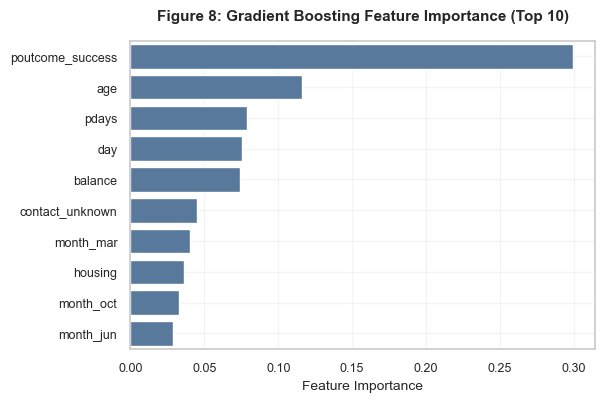

Feature,Importance
poutcome_success,0.299537
age,0.115926
pdays,0.079118
day,0.075253
balance,0.074262
contact_unknown,0.045069
month_mar,0.040290
housing,0.035988
month_oct,0.032789
month_jun,0.028708


In [29]:
# Feature Importance
importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
}).sort_values(by = 'Importance', ascending = False)

importance_xgb = importance_xgb.round(6)

# Plot: Feature Importance
sns.set_theme(style = 'whitegrid')

plt.figure(figsize = (6, 4))

ax = sns.barplot(
    data = importance_xgb.head(10),
    x = 'Importance',
    y = 'Feature',
    color = '#4C78A8',
    edgecolor = 'white',
    linewidth = 1
)

ax.set_xlabel('Feature Importance', fontsize = 10)
ax.set_ylabel('')

ax.tick_params(axis = 'both', labelsize = 9)

ax.set_axisbelow(True)
ax.grid(True, alpha = 0.2)

plt.title(
    'Figure 8: Gradient Boosting Feature Importance (Top 10)',
    fontsize = 11,
    fontweight = 'bold',
    pad = 15
)

plt.show()

display(HTML('<br><b>Table A3: Gradient Boosting Feature Importance (Top 10)</b>'))
display(
    importance_xgb.head(10)
        .style
        .hide(axis = 'index')
        .set_properties(subset = ['Feature'], **{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th.col_heading.level0.col0',
             'props': [('text-align', 'left')]}
        ])
)


The boosting model achieves the strongest classification performance among the models considered, as reflected by its test AUC and competitive test error. These results suggest that the boosting approach is able to capture complex patterns in the data while maintaining stable predictive performance on unseen data.


## Results

This section presents the empirical results obtained from applying the classification methods to the Bank Marketing dataset. Model performance is evaluated using misclassification error on both training and test data, with results reported for a single hold-out train-test split as well as for Monte Carlo cross-validation. These complementary evaluation approaches allow for comparison of predictive accuracy, generalization performance, and model stability across different data partitions. The results are used to identify the classification method that provides the strongest predictive performance while also illustrating the tradeoffs between model complexity and interpretability.


### Model Performance Evaluation

Model performance across the three classifiers is summarized in **Table 4** using training and test misclassification error and AUC. Logistic regression provides a strong baseline with a test error of 0.1069 and a test AUC of 0.7733. The random forest model improves predictive performance relative to the logistic model, achieving a lower test error (0.1041) and higher test AUC (0.7999), although its substantially higher training AUC (0.9457) suggests some degree of overfitting. The gradient boosting model provides the strongest overall performance, producing the highest test AUC (0.8058) and competitive test error (0.1046), indicating improved classification discrimination on unseen data.


In [32]:
# Logistic Regression Errors
train_error_logit = 1 - accuracy_score(y_train, y_train_pred)
test_error_logit = 1 - accuracy_score(y_test, y_test_pred)

# Random Forest Errors
train_error_rf = 1 - accuracy_score(y_train, y_train_pred_rf)
test_error_rf = 1 - accuracy_score(y_test, y_test_pred_rf)

# Gradient Boosting Errors
train_error_gb = 1 - accuracy_score(y_train, y_train_pred_gb)
test_error_gb = 1 - accuracy_score(y_test, y_test_pred_gb)

# Model Comparison Table
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Training Error': [
        train_error_logit,
        train_error_rf,
        train_error_gb
    ],
    'Test Error': [
        test_error_logit,
        test_error_rf,
        test_error_gb
    ],
    'Training AUC': [
        train_auc,
        train_auc_rf,
        train_auc_gb
    ],
    'Test AUC': [
        test_auc,
        test_auc_rf,
        test_auc_gb
    ]
})

model_results = model_results.round(4)

model_results = model_results.sort_values(
    by = 'Test Error',
    ascending = True
)

display(HTML('<br><b>Table 4: Training & Test Performance Comparison Across Models</b>'))

display(
    model_results.style
        .hide(axis = 'index')
        .set_properties(subset = ['Model'], **{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th.col_heading.level0.col0',
             'props': [('text-align', 'left')]}
        ])
)


Model,Training Error,Test Error,Training AUC,Test AUC
Random Forest,0.093500,0.104100,0.945700,0.799900
Gradient Boosting,0.090800,0.104600,0.835900,0.805800
Logistic Regression,0.108200,0.106900,0.765600,0.773300


**Figure 9** presents the ROC curves for the three models evaluated on the test set. Consistent with the AUC results reported in **Table 4**, the gradient boosting model demonstrates the strongest discriminative performance, followed by random forest and logistic regression. Although the differences in test misclassification error across models are relatively small, the ROC analysis indicates that boosting provides the best overall predictive performance for this dataset.


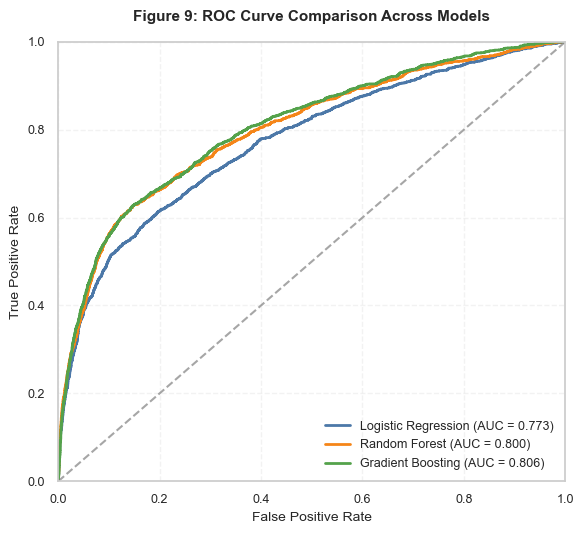

In [33]:
# Plot: ROC Curve
y_prob_logit = logit_model.predict_proba(X_test_scaled)[:,1]
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

fpr_logit, tpr_logit, _ = roc_curve(y_test, y_prob_logit)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize = (6, 5.5))

# Logistic Regression
plt.plot(
    fpr_logit, tpr_logit,
    linewidth = 2,
    color = '#4C78A8',
    label = f'Logistic Regression (AUC = {test_auc:.3f})'
)

# Random Forest
plt.plot(
    fpr_rf, tpr_rf,
    linewidth = 2,
    color = '#F58518',
    label = f'Random Forest (AUC = {test_auc_rf:.3f})'
)

# Gradient Boosting
plt.plot(
    fpr_gb, tpr_gb,
    linewidth = 2,
    color = '#54A24B',
    label = f'Gradient Boosting (AUC = {test_auc_gb:.3f})'
)

plt.plot(
    [0,1],[0,1],
    linestyle = '--',
    linewidth = 1.5,
    color = 'gray',
    alpha = 0.7
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel('False Positive Rate', fontsize = 10)
plt.ylabel('True Positive Rate', fontsize = 10)

plt.xticks(fontsize = 9)
plt.yticks(fontsize = 9)

# Plot: ROC Comparison Curves
plt.title(
    'Figure 9: ROC Curve Comparison Across Models',
    fontsize = 11,
    fontweight = 'bold',
    pad = 15
)

plt.legend(
    frameon = False,
    fontsize = 9,
    loc = 'lower right'
)

plt.grid(
    alpha = 0.25,
    linestyle = '--'
)

plt.tight_layout()
plt.show()


### Feature Importance

To understand how each modeling approach identifies influential predictors, feature importance measures were compared across logistic regression, random forest, and gradient boosting models. Because these methods use different importance metrics, including coefficient magnitude for logistic regression and impurity-based measures for tree-based models, the values were normalized within each model to enable meaningful comparison. **Figure 10** presents a heatmap of the most influential predictors across the three models.

The results show both common and model-specific patterns. The variable <code>poutcome_success</code> is an important predictor across all models, particularly for random forest and gradient boosting, indicating that prior successful marketing outcomes strongly increase the likelihood of subscription. Tree-based models also place greater emphasis on continuous variables such as <code>age</code>, <code>balance</code>, <code>day</code>, and <code>pdays</code>, reflecting their ability to capture nonlinear relationships and interactions.

In contrast, the logistic regression model assigns relatively higher importance to campaign and contact-related indicators, including <code>contact_unknown</code> and seasonal month variables such as <code>month_mar</code>, <code>month_aug</code>, <code>month_jul</code>, and <code>month_nov</code>, while also giving moderate importance to <code>housing</code>. These differences highlight how linear and tree-based models capture relationships in distinct ways while identifying several predictors that consistently contribute to model performance.


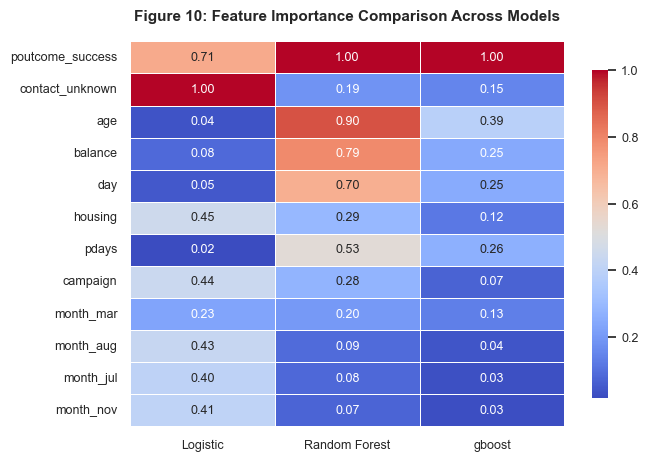

In [36]:
# Feature Importance
logit_imp = pd.Series(np.abs(logit_model.coef_[0]), index = X_train.columns)
rf_imp = pd.Series(rf_model.feature_importances_, index = X_train.columns)
gb_imp = pd.Series(gb_model.feature_importances_, index = X_train.columns)

importance_compare = pd.DataFrame({
    'Logistic': logit_imp,
    'Random Forest': rf_imp,
    'gboost': gb_imp
})

importance_compare = importance_compare / importance_compare.max()

top_features = importance_compare.mean(axis = 1)\
    .sort_values(ascending = False)\
    .head(12)\
    .index

importance_compare = importance_compare.loc[top_features]

# Heatmap: Feature Importance
sns.set_theme(style = 'whitegrid')

plt.figure(figsize = (7, 5))

ax = sns.heatmap(
    importance_compare,
    cmap = 'coolwarm',
    annot = True,
    fmt = '.2f',
    linewidths = 0.5,
    annot_kws = {'size': 9},
    cbar_kws = {'shrink': 0.85}
)

ax.collections[0].colorbar.ax.tick_params(labelsize = 9)

ax.set_ylabel('', fontsize = 9)
ax.set_xlabel('', fontsize = 9)
ax.tick_params(axis = 'both', labelsize = 9)

plt.title(
    'Figure 10: Feature Importance Comparison Across Models',
    fontsize = 11,
    fontweight = 'bold',
    pad = 15
)

plt.show()


### Monte Carlo Cross-Validation

To obtain more stable estimates of predictive performance, Monte Carlo cross-validation using repeated random training and test splits was conducted. While a single hold-out split provides an initial estimate of predictive performance, the resulting error rates may depend on the particular partition of the data. Therefore, Monte Carlo cross-validation was implemented by repeatedly generating random training and test splits and evaluating each model across these replications. In each iteration, the data were randomly partitioned into training and test sets, the models were estimated using the training data, and predictive performance was evaluated on the corresponding test data.


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Cross-Validation Performance.
</span>
The Monte Carlo cross-validation results across 100 replications for the three models considered in this study, logistic regression, random forest, and gradient boosting, are summarized in <b>Table 5</b>. The random forest model achieves the lowest mean test error (0.1054), while the boosting model achieves the highest mean test AUC (0.7990). Both ensemble methods outperform logistic regression, which produces a higher mean test error (0.1089) and a lower mean test AUC (0.7626). These results suggest that tree-based ensemble models capture nonlinear relationships and interactions among predictors more effectively than the linear logistic regression model.


In [37]:
# Monte Carlo Cross-Validation
rng = np.random.default_rng(7)
random_seeds = rng.integers(0, 10_000, size = 100)

mccv_results = {
    'Logistic Regression': {'train_error': [], 'test_error': [], 'train_auc': [], 'test_auc': []},
    'Random Forest': {'train_error': [], 'test_error': [], 'train_auc': [], 'test_auc': []},
    'Boosting': {'train_error': [], 'test_error': [], 'train_auc': [], 'test_auc': []}
}

numeric_cols = X.select_dtypes(include = ['int64','float64']).columns
categorical_cols = X.select_dtypes(include = ['object']).columns

for seed in random_seeds:

    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size = 0.30,
        stratify = y,
        random_state = seed
    )

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers = [
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'), categorical_cols)
        ]
    )

    X_train_proc = preprocessor.fit_transform(X_train)
    X_test_proc = preprocessor.transform(X_test)

    # Logistic Regression w/Tuned Hyperperameters
    logit = LogisticRegression(
        C = 0.01,
        penalty = 'l2',
        max_iter = 5000,
        random_state = 7
    )

    logit.fit(X_train_proc, y_train)

    y_train_pred = logit.predict(X_train_proc)
    y_test_pred = logit.predict(X_test_proc)

    y_train_prob = logit.predict_proba(X_train_proc)[:,1]
    y_test_prob = logit.predict_proba(X_test_proc)[:,1]

    mccv_results['Logistic Regression']['train_error'].append(1 - accuracy_score(y_train, y_train_pred))
    mccv_results['Logistic Regression']['test_error'].append(1 - accuracy_score(y_test, y_test_pred))
    mccv_results['Logistic Regression']['train_auc'].append(roc_auc_score(y_train, y_train_prob))
    mccv_results['Logistic Regression']['test_auc'].append(roc_auc_score(y_test, y_test_prob))

    # Random Forest w/Tuned Hyperperameters
    rf = RandomForestClassifier(
        n_estimators = 200,
        max_features = 'sqrt',
        max_depth = 20,
        min_samples_leaf = 5,
        random_state = 7,
        n_jobs = 6
    )

    rf.fit(X_train_proc, y_train)

    y_train_pred = rf.predict(X_train_proc)
    y_test_pred = rf.predict(X_test_proc)

    y_train_prob = rf.predict_proba(X_train_proc)[:,1]
    y_test_prob = rf.predict_proba(X_test_proc)[:,1]

    mccv_results['Random Forest']['train_error'].append(1 - accuracy_score(y_train, y_train_pred))
    mccv_results['Random Forest']['test_error'].append(1 - accuracy_score(y_test, y_test_pred))
    mccv_results['Random Forest']['train_auc'].append(roc_auc_score(y_train, y_train_prob))
    mccv_results['Random Forest']['test_auc'].append(roc_auc_score(y_test, y_test_prob))

    # Gradient Boosting w/Tuned Hyperperameters
    gb = GradientBoostingClassifier(
        n_estimators = 200,
        learning_rate = 0.1,
        max_depth = 4,
        min_samples_leaf = 5,
        random_state = 7
    )

    gb.fit(X_train_proc, y_train)

    y_train_pred = gb.predict(X_train_proc)
    y_test_pred = gb.predict(X_test_proc)

    y_train_prob = gb.predict_proba(X_train_proc)[:,1]
    y_test_prob = gb.predict_proba(X_test_proc)[:,1]

    mccv_results['Boosting']['train_error'].append(1 - accuracy_score(y_train, y_train_pred))
    mccv_results['Boosting']['test_error'].append(1 - accuracy_score(y_test, y_test_pred))
    mccv_results['Boosting']['train_auc'].append(roc_auc_score(y_train, y_train_prob))
    mccv_results['Boosting']['test_auc'].append(roc_auc_score(y_test, y_test_prob))

# Summary Table
mccv_summary = pd.DataFrame({
    model: {
        'Mean Training Error': np.mean(vals['train_error']),
        'Training Error Std. Dev.': np.std(vals['train_error'], ddof = 1),
        'Mean Test Error': np.mean(vals['test_error']),
        'Test Error Std. Dev.': np.std(vals['test_error'], ddof = 1),
        'Mean Training AUC': np.mean(vals['train_auc']),
        'Training AUC Std. Dev.': np.std(vals['train_auc'], ddof = 1),
        'Mean Test AUC': np.mean(vals['test_auc']),
        'Test AUC Std. Dev.': np.std(vals['test_auc'], ddof = 1)
    }
    for model, vals in mccv_results.items()
}).T

mccv_summary = mccv_summary.sort_values('Mean Test Error').reset_index()
mccv_summary = mccv_summary.rename(columns = {'index':'Model'})
mccv_summary = mccv_summary.round(4)


In [38]:
# Monte Carlo Cross-Validation Summary
mccv_display = mccv_summary[
    [
        'Model',
        'Mean Test Error',
        'Test Error Std. Dev.',
        'Mean Test AUC',
        'Test AUC Std. Dev.'
    ]
]

display(HTML('<br><b>Table 5: Monte Carlo Cross-Validation Summary of Model Performance</b>'))
display(
    mccv_display
        .style
        .hide(axis = 'index')
        .set_properties(subset = ['Model'], **{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th.col_heading.level0.col0',
             'props': [('text-align', 'left')]}
        ])
)


Model,Mean Test Error,Test Error Std. Dev.,Mean Test AUC,Test AUC Std. Dev.
Random Forest,0.105400,0.001100,0.795900,0.005600
Boosting,0.106400,0.001500,0.799000,0.005900
Logistic Regression,0.108900,0.000800,0.762600,0.005800


Although the differences among models are relatively small, the results consistently indicate that the ensemble methods provide modest improvements in predictive performance relative to logistic regression. In particular, the higher AUC values for the tree-based models suggest stronger discrimination between subscription and non-subscription outcomes across classification thresholds. The small standard deviations for both test error and test AUC indicate stable performance across repeated training and test partitions. The Monte Carlo cross-validation results confirm the patterns observed in the single hold-out evaluation, with random forest achieving the lowest average classification error and gradient boosting achieving the highest average AUC across repeated samples<span style="color: darkred; font-weight: bold;"><sup>4</sup></span>.

---

<div style="margin-left:20px; text-indent:-10px;">
<span style="color: darkred; font-weight: bold;"><sup>4</sup></span> 
    Statistical significance testing was not conducted for the Monte Carlo cross-validation results because the repeated train-test splits are generated from the same dataset and therefore do not produce fully independent performance estimates. As a result, the relatively small differences in model performance should be viewed as general comparisons rather than definitive proof that one model statistically outperforms another.
</div>


## Conclusions & Model Selection

This study evaluated three classification approaches for predicting client subscription outcomes: logistic regression, random forest, and boosting. Model performance was first assessed using a single hold-out training and test split and then evaluated more rigorously using Monte Carlo cross-validation across 100 replications.<br><br>

<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Hold-Out Evaluation Results.
</span>
The hold-out evaluation indicates that the ensemble models slightly outperform logistic regression. Gradient boosting achieves the highest test AUC (0.7982) and the lowest test error (0.1028), while random forest produces a similar test error (0.1038) with a slightly lower AUC of 0.7958. Logistic regression achieves a test error of 0.1056 and a test AUC of 0.7702, providing a strong but slightly weaker baseline relative to the ensemble approaches. The ROC curve comparison further illustrates that boosting provides the strongest overall discrimination between subscription and non-subscription outcomes.<br><br>

<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Monte Carlo Cross-Validation Results.
</span>
The Monte Carlo cross-validation analysis reinforces these findings. Across 100 replications, the random forest achieves the lowest mean test error (0.1054), while the boosting model achieves the highest mean test AUC (0.7990), followed by random forest and logistic regression. Although the performance differences are relatively small, the ensemble models consistently outperform the baseline logistic regression model in terms of both predictive accuracy and classification discrimination.<br><br>

<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Feature Importance Comparison.
</span>
An examination of feature importance across models provides additional insight into the drivers of predictive performance. Several predictors emerge as influential across multiple models, particularly poutcome_success, which consistently appears among the most important variables. The tree-based models also emphasize continuous customer characteristics such as balance, age, and day, while logistic regression places relatively greater emphasis on marketing-related categorical variables including contact_unknown, housing, and several month indicators. These differences reflect the distinct ways in which linear and tree-based models capture relationships within the data.<br><br>

<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Final Model Selection.
</span>
Based on the combined evidence from the hold-out evaluation, ROC analysis, and Monte Carlo cross-validation results, <b><u>the gradient boosting model is selected as the preferred predictive model</u></b> for this study. Although random forest achieves the lowest average classification error across replications, the boosting model consistently produces the highest AUC, indicating stronger discrimination between subscription and non-subscription outcomes across classification thresholds. Because the differences in classification error among the ensemble models are small, the superior AUC performance of boosting provides a meaningful advantage. In addition, the boosting framework offers flexibility for capturing nonlinear relationships and interactions among predictors.
